# Day 6 — CNN Project 3: CIFAR-10

**Focus:** RGB images · Multiclass classification · Softmax · Confusion matrix · Error analysis · Data augmentation

## Three CNN examples for Day 6

| Example | Type | Classes | Image | Main teaching purpose |
|---|---|---|---|---|
| **MNIST** | Multiclass | 10 | 28×28 grayscale | Understand CNN fundamentals |
| **Cats vs Dogs** | Binary | 2 | RGB | Real-world binary classification |
| **CIFAR-10** | Multiclass | 10 | 32×32 RGB | More difficult color/object classification |

**CIFAR-10 classes:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

**Progression:**
```
MNIST        -> simple grayscale images
   ↓
Cats vs Dogs -> real RGB images / binary
   ↓
CIFAR-10     -> RGB images / 10 classes / multiple object types
```

CIFAR-10 is built into TensorFlow/Keras, so there is no need to download another dataset.

## 0. Load the data

In [1]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

Check the data:

In [2]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


You should see approximately:

```
X_train: (50000, 32, 32, 3)
y_train: (50000, 1)

X_test:  (10000, 32, 32, 3)
y_test:  (10000, 1)
```

Explain the image shape:

```
32 × 32 × 3
         ↑
   RGB color image
```

## 1. Visualize CIFAR-10

Display several examples. This shows immediately why CIFAR-10 is more challenging than MNIST.

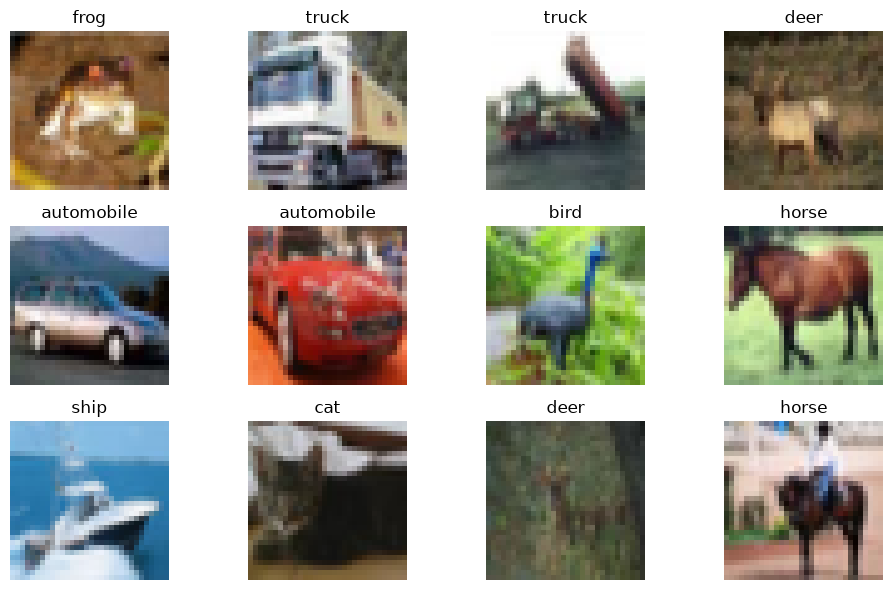

In [3]:
import matplotlib.pyplot as plt

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Normalize the images and create validation data

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (45000, 32, 32, 3) | Val: (5000, 32, 32, 3) | Test: (10000, 32, 32, 3)


## 3. Build the CIFAR-10 CNN

Start with a relatively simple CNN so students understand it.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(10, activation="softmax")
])

C:\Users\PC-LAB1\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ Board exercise: calculate the feature-map dimensions manually

Formula for a `3×3` convolution (no padding, stride 1): `output = input − 3 + 1`. A `2×2` max-pool halves each side (rounded down).

```
Input          32 × 32 × 3
   ↓ Conv2D
               30 × 30 × 32
   ↓ MaxPooling
               15 × 15 × 32
   ↓ Conv2D
               13 × 13 × 64
   ↓ MaxPooling
                6 × 6 × 64
```

**Your turn:** continue the calculation for the third Conv2D (128 filters) and its MaxPooling, then compute the size after `Flatten()`. Compare with `model.summary()`.

## 4. Compile

Why these choices?

```
10 classes
    ↓
softmax
    ↓
sparse_categorical_crossentropy
```

Labels are integers (0–9), so we use the *sparse* version of categorical cross-entropy.

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 5. Train

Students should monitor: **training accuracy**, **validation accuracy**, **training loss**, **validation loss**.

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.7125 - loss: 0.8275 - val_accuracy: 0.7030 - val_loss: 0.8449
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.7252 - loss: 0.7848 - val_accuracy: 0.7116 - val_loss: 0.8249
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.7379 - loss: 0.7531 - val_accuracy: 0.7098 - val_loss: 0.8390
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.7498 - loss: 0.7191 - val_accuracy: 0.7108 - val_loss: 0.8312
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.7610 - loss: 0.6847 - val_accuracy: 0.7178 - val_loss: 0.8159
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.7750 - loss: 0.6464 - val_accuracy: 0.7274 - val_loss: 0.7984
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.7807 - loss: 0.6254 - val_accuracy: 0.7312 - val_loss: 0.7998
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.7870 - loss: 0.6065 - 

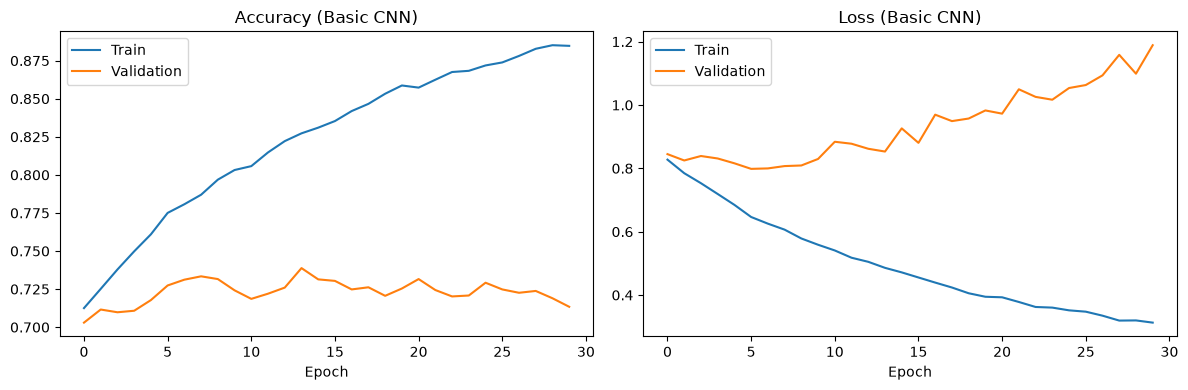

In [13]:
def plot_history(h, title=""):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(h.history["accuracy"], label="Train")
    plt.plot(h.history["val_accuracy"], label="Validation")
    plt.title(f"Accuracy {title}")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h.history["loss"], label="Train")
    plt.plot(h.history["val_loss"], label="Validation")
    plt.title(f"Loss {title}")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history, "(Basic CNN)")

**Discussion:** Is the gap between training and validation curves growing? What does that suggest?

## 6. Evaluate

In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7173 - loss: 1.2129
Test accuracy: 0.7172999978065491


Then generate predictions:

In [15]:
predictions = model.predict(X_test)

y_pred = predictions.argmax(axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## 7. Confusion matrix

This is especially interesting for CIFAR-10.

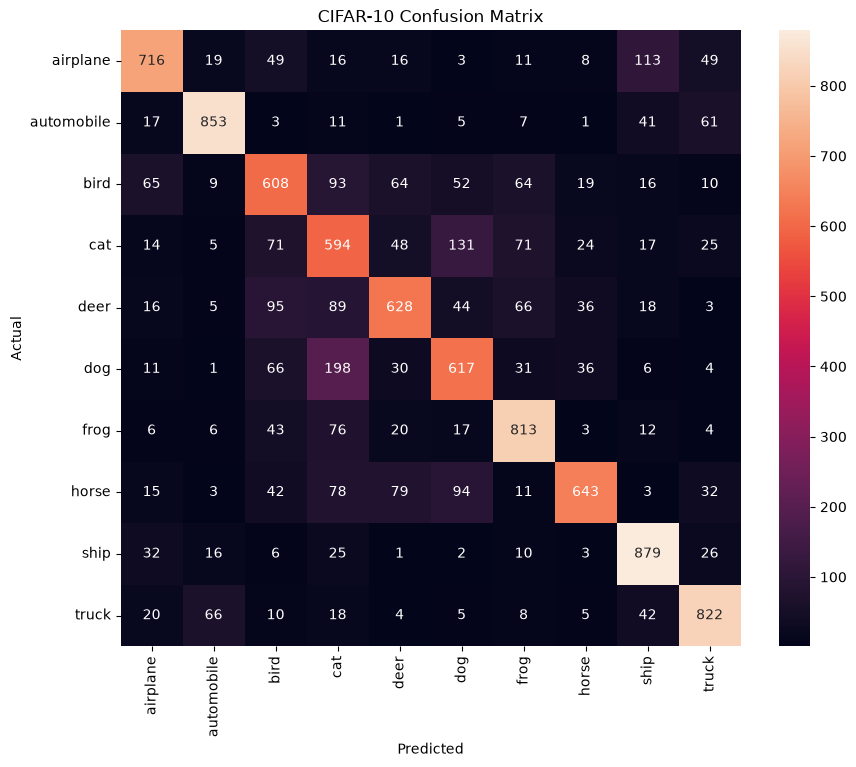

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CIFAR-10 Confusion Matrix")

plt.show()

Students can investigate questions such as: **Which classes does the CNN confuse?**

For example, they may observe confusion between visually similar categories such as automobiles/trucks or cats/dogs. The important lesson is to **inspect the model's actual confusion matrix**, rather than assuming all classes are equally difficult.

## 8. Show incorrect predictions

Visually inspecting *why the CNN made mistakes* is much more educational than just reporting accuracy.

In [17]:
wrong = []

for i in range(len(y_test)):
    if y_true[i] != y_pred[i]:
        wrong.append(i)

print("Number of wrong predictions:", len(wrong))

Number of wrong predictions: 2827


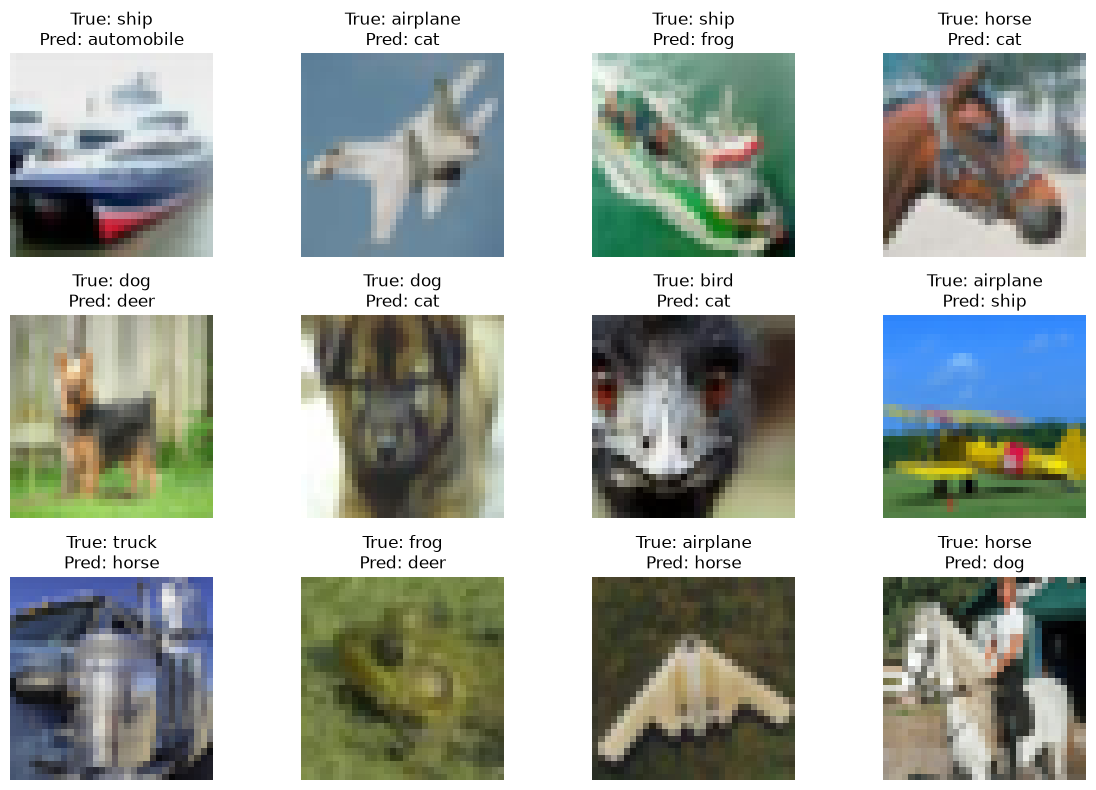

In [18]:
plt.figure(figsize=(12, 8))

for j, i in enumerate(wrong[:12]):

    plt.subplot(3, 4, j + 1)

    plt.imshow(X_test[i])

    plt.title(
        f"True: {class_names[y_true[i]]}\n"
        f"Pred: {class_names[y_pred[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Add data augmentation

After the basic CNN works, improve it. Then compare:

```
CNN
 vs
CNN + Data Augmentation
```

In [19]:
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [20]:
model_aug = Sequential([

    data_augmentation,

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(10, activation="softmax")
])

model_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_aug = model_aug.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3110 - loss: 1.8571 - val_accuracy: 0.4530 - val_loss: 1.4930
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4322 - loss: 1.5556 - val_accuracy: 0.4664 - val_loss: 1.4764
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4803 - loss: 1.4504 - val_accuracy: 0.5216 - val_loss: 1.2998
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5122 - loss: 1.3659 - val_accuracy: 0.5652 - val_loss: 1.2170
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5358 - loss: 1.3086 - val_accuracy: 0.5844 - val_loss: 1.1813
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5550 - loss: 1.2651 - val_accuracy: 0.5990 - val_loss: 1.1131
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5693 - loss: 1.2245 - val_accuracy: 0.5986 - val_loss: 1.1168
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5796 - loss: 1.1982 - val_accu

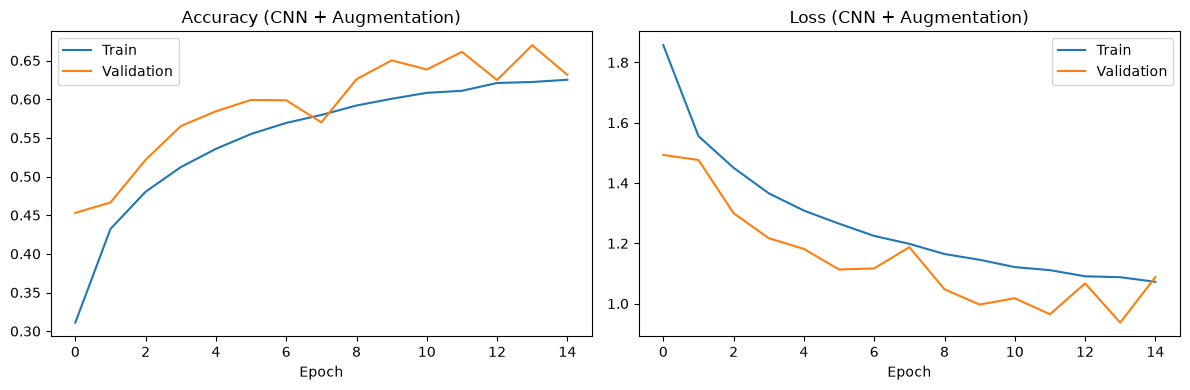

Basic CNN test accuracy:        0.7173
CNN + Augmentation test accuracy: 0.6187


In [21]:
plot_history(history_aug, "(CNN + Augmentation)")

aug_loss, aug_acc = model_aug.evaluate(X_test, y_test, verbose=0)
print(f"Basic CNN test accuracy:        {test_accuracy:.4f}")
print(f"CNN + Augmentation test accuracy: {aug_acc:.4f}")

## 10. (Optional, advanced) Transfer learning

Since your students are advanced, this is an **optional advanced exercise**, not the main lesson.

Use CIFAR-10 and a pretrained model such as **MobileNetV2**. The conceptual pipeline:

```
Pretrained CNN
      ↓
Learned features
      ↓
New classification head
      ↓
CIFAR-10 classes
```

This introduces **Transfer Learning** without requiring students to train a huge network from scratch.

> Note: pretrained MobileNetV2 weights (ImageNet) need inputs of at least 96×96, so we upscale the 32×32 images inside the model. Internet access is needed the first time to download the weights.

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False   # freeze the pretrained features

inputs = layers.Input(shape=(32, 32, 3))
x = layers.Resizing(96, 96)(inputs)
x = layers.Rescaling(255.0)(x)            # back to 0-255
x = layers.Lambda(preprocess_input)(x)    # MobileNetV2 expects [-1, 1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation="softmax")(x)

transfer_model = models.Model(inputs, outputs)

transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step



Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
history_tl = transfer_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

tl_loss, tl_acc = transfer_model.evaluate(X_test, y_test, verbose=0)
print(f"Transfer learning test accuracy: {tl_acc:.4f}")

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 99ms/step - accuracy: 0.7726 - loss: 0.6802 - val_accuracy: 0.8498 - val_loss: 0.4290
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 98ms/step - accuracy: 0.8350 - loss: 0.4826 - val_accuracy: 0.8560 - val_loss: 0.4090
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.8443 - loss: 0.4544 - val_accuracy: 0.8648 - val_loss: 0.3858
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 97ms/step - accuracy: 0.8473 - loss: 0.4472 - val_accuracy: 0.8624 - val_loss: 0.4017
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 99ms/step - accuracy: 0.8516 - loss: 0.4365 - val_accuracy: 0.8656 - val_loss: 0.3802
Transfer learning test accuracy: 0.8596


## Summary of Day 6 structure

| Part | Topic |
|---|---|
| 1 | Deep Learning fundamentals — neuron, weights, bias, activation, forward propagation, loss, backpropagation, gradient descent |
| 2 | MLP — MNIST (28×28 → Flatten → Dense → Dense → 10 classes) |
| 3 | CNN fundamentals — Image → Conv → ReLU → Pool → Conv → Pool → Flatten → Dense → Output |
| 4 | CNN Project 1 — **MNIST CNN** (understand the architecture) |
| 5 | CNN Project 2 — **Cats vs Dogs** (RGB, binary, sigmoid, binary cross-entropy, augmentation, overfitting) |
| 6 | CNN Project 3 — **CIFAR-10** (RGB, multiclass, softmax, confusion matrix, error analysis, augmentation) |
| 7 | Advanced — **Transfer Learning** |

```
DAY 5  Classical Computer Vision
        ├── Image processing
        ├── Feature extraction
        ├── HOG
        ├── SVM
        └── MLP
               ▼
DAY 6  Deep Learning
        ├── Neural Networks
        ├── MLP
        └── CNN
             ├── MNIST
             ├── Cats vs Dogs
             └── CIFAR-10
                    ▼
              Transfer Learning
```